<a href="https://colab.research.google.com/github/mkg6573/Social_media_impact_on_life_ML_/blob/main/Supervised%20Learning%20Algorithms/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/Social_media_impact_on_life_Clean_Dataset.csv")
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,1.6,LinkedIn,No,8.6,7.6,Positive
2,22,Male,Graduate,4.6,Instagram,No,6.7,7.0,Neutral
3,18,Male,Undergraduate,7.0,Snapchat,Yes,5.4,5.3,Negative
4,24,Female,High School,7.5,Facebook,Yes,5.0,4.4,Negative


In [5]:
df.shape

(1705, 9)

In [16]:
df = df.drop('Mental_Health_Score', axis=1)

In [19]:
df.shape

(1705, 8)

In [20]:
X = df.drop("Overall_Impact", axis=1)
y = df["Overall_Impact"]

Separate Numerical and Categorical Columns

In [21]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

Create Preprocessing Pipeline

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [23]:
# Numerical columns pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical columns pipeline
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [24]:
# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [26]:
X_train.shape

(1364, 7)

In [27]:
X_test.shape

(341, 7)

In [28]:
X_train.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night
1380,19,Female,Undergraduate,4.6,Instagram,Yes,7.3
251,21,Male,Undergraduate,5.6,Facebook,No,6.0
967,23,Male,Graduate,8.4,Twitter,Yes,4.6
745,18,Female,Undergraduate,2.5,LinkedIn,No,7.3
1582,20,Female,Undergraduate,6.7,Instagram,Yes,6.0


Create Logistic Regression Pipeline

In [30]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [31]:
iters = [50, 100, 200, 500, 1000, 2000, 3000, 5000, 7000, 10000]

acc_list = []

for i in iters:
    # Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=i))
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    acc_list.append(acc)

    print("max_iter =", i, " Accuracy =", acc)

max_iter = 50  Accuracy = 0.873900293255132
max_iter = 100  Accuracy = 0.873900293255132
max_iter = 200  Accuracy = 0.873900293255132
max_iter = 500  Accuracy = 0.873900293255132
max_iter = 1000  Accuracy = 0.873900293255132
max_iter = 2000  Accuracy = 0.873900293255132
max_iter = 3000  Accuracy = 0.873900293255132
max_iter = 5000  Accuracy = 0.873900293255132
max_iter = 7000  Accuracy = 0.873900293255132
max_iter = 10000  Accuracy = 0.873900293255132


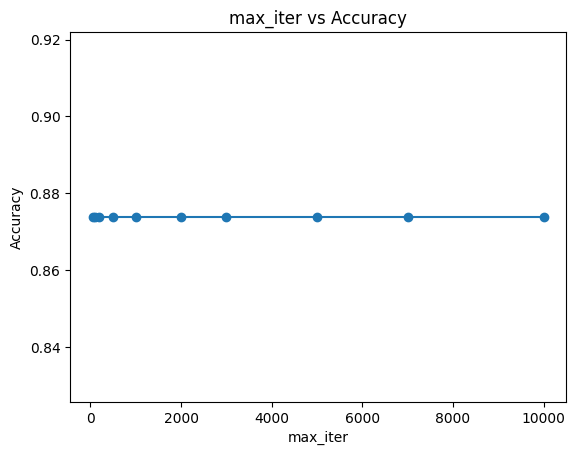

In [32]:
# Graph
plt.plot(iters, acc_list, marker='o')

plt.xlabel("max_iter")
plt.ylabel("Accuracy")
plt.title("max_iter vs Accuracy")

plt.show()

Accuracy is same because the model already converged early.

That means after some iterations, the weights stop changing significantly.

So increasing max_iter further does not improve learning.

In [33]:
pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=100))
    ])

In [34]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [35]:
acc

0.873900293255132

#**So we have accuracy of 87.39%**